# BO-LogEI

device: cuda


/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([-0.0539], device='cuda:0', dtype=torch.float64), std = tensor([0.3607], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


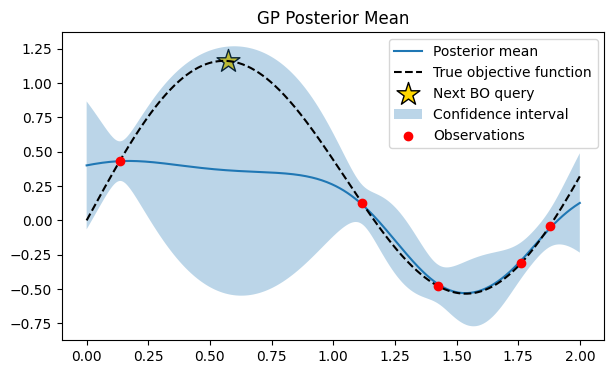

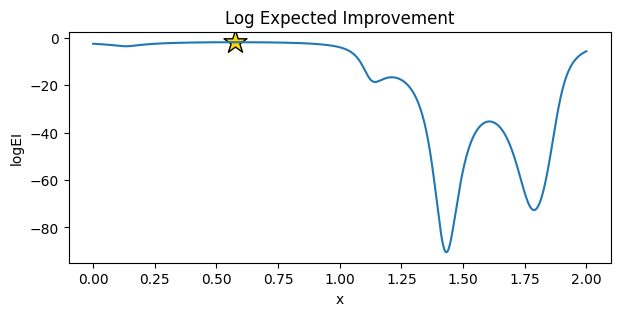

In [ ]:
import torch
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.optim import optimize_acqf

from gpytorch.mlls import ExactMarginalLogLikelihood

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double   # 强烈推荐 double（GP 数值稳定）
print('device:', device)

def objective(x):
    # x: (n, 1)
    return torch.sin(3 * x) + 0.3 * x

torch.manual_seed(0)

# 搜索空间
bounds = torch.tensor([[0.0], [2.0]], device=device, dtype=dtype)

# 初始采样点
train_x = (torch.rand(5, 1, device=device, dtype=dtype) * 2.0)
train_y = objective(train_x).to(device=device, dtype=dtype)


model = SingleTaskGP(train_x, train_y)
model = model.to(device=device, dtype=dtype)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

best_f = train_y.max()

acqf = LogExpectedImprovement(
    model=model,
    best_f=best_f
).to(device=device, dtype=dtype)

# 评估网格
X = torch.linspace(0, 2, 500, device=device, dtype=dtype).unsqueeze(-1)
X_acq = X.unsqueeze(1)   # (500, 1, 1)

# 后验
posterior = model.posterior(X)
mean = posterior.mean.squeeze(-1).detach()
var = posterior.variance.squeeze(-1).detach()

# 获取函数
with torch.no_grad():
    log_ei = acqf(X_acq).squeeze(-1)


candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=64,)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidate.cpu().numpy(), objective(candidate).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("GP Posterior Mean")
plt.legend()
plt.show()


plt.figure(figsize=(7, 3))

plt.plot(X.cpu().numpy(), log_ei.cpu().numpy())
plt.scatter(candidate.cpu().numpy(), acq_value.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.title("Log Expected Improvement")
plt.xlabel("x")
plt.ylabel("logEI")

plt.show()


# BO-EI

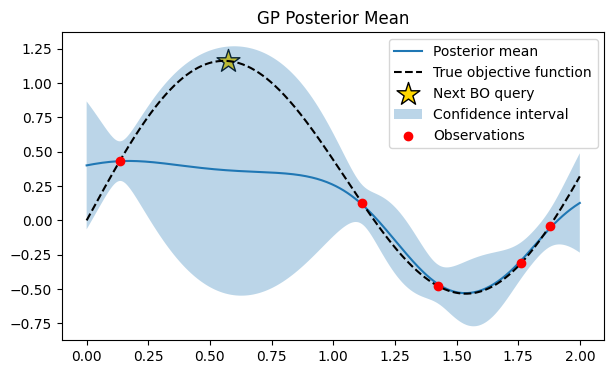

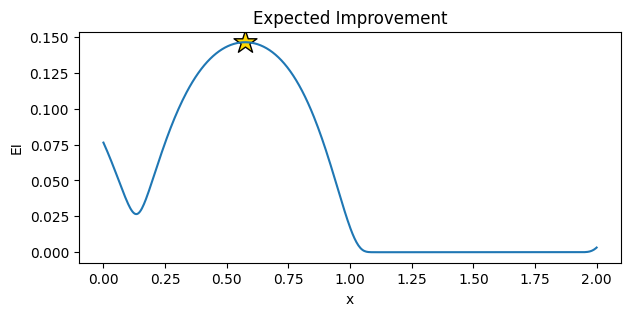

In [ ]:

from botorch.acquisition.analytic import ExpectedImprovement


best_f = train_y.max()

acqf = ExpectedImprovement(
    model=model,
    best_f=best_f
).to(device=device, dtype=dtype)

# 获取函数
with torch.no_grad():
    ei = acqf(X_acq).squeeze(-1)


candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=64,)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidate.cpu().numpy(), objective(candidate).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("GP Posterior Mean")
plt.legend()
plt.show()



plt.figure(figsize=(7, 3))

plt.plot(X.cpu().numpy(), ei.cpu().numpy())
plt.scatter(candidate.cpu().numpy(), acq_value.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.title("Expected Improvement")
plt.xlabel("x")
plt.ylabel("EI")

plt.show()




# BO-UCB

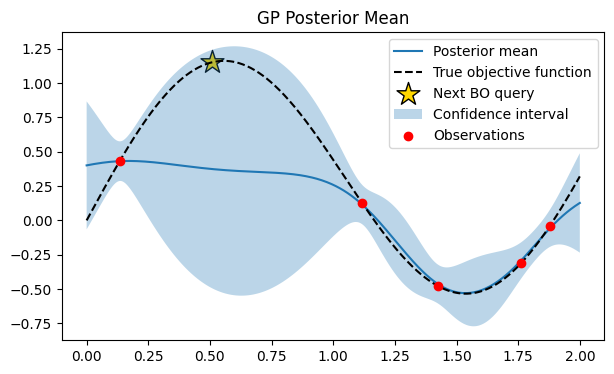

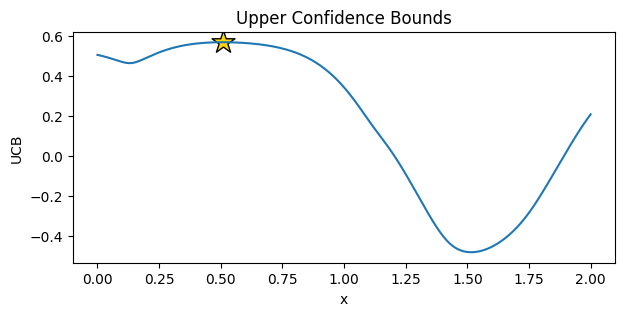

In [55]:

from botorch.acquisition.analytic import UpperConfidenceBound


acqf = UpperConfidenceBound(
    model=model,
    beta=0.2
).to(device=device, dtype=dtype)

# 获取函数
with torch.no_grad():
    ucb = acqf(X_acq).squeeze(-1)


candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=64,)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidate.cpu().numpy(), objective(candidate).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("GP Posterior Mean")
plt.legend()
plt.show()



plt.figure(figsize=(7, 3))

plt.plot(X.cpu().numpy(), ucb.cpu().numpy())
plt.scatter(candidate.cpu().numpy(), acq_value.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.title("Upper Confidence Bounds")
plt.xlabel("x")
plt.ylabel("UCB")

plt.show()


# BO-KG  （q=1）

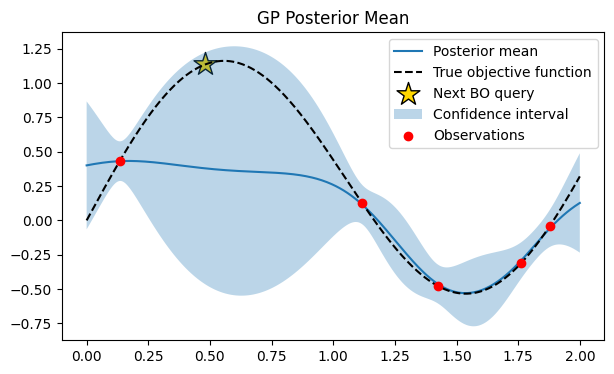

In [ ]:

from botorch.acquisition.knowledge_gradient import qKnowledgeGradient


acqf = qKnowledgeGradient(
    model=model,
).to(device=device, dtype=dtype)


candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=64,)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidate.cpu().numpy(), objective(candidate).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("GP Posterior Mean")
plt.legend()
plt.show()






# BO-PES(q=1)

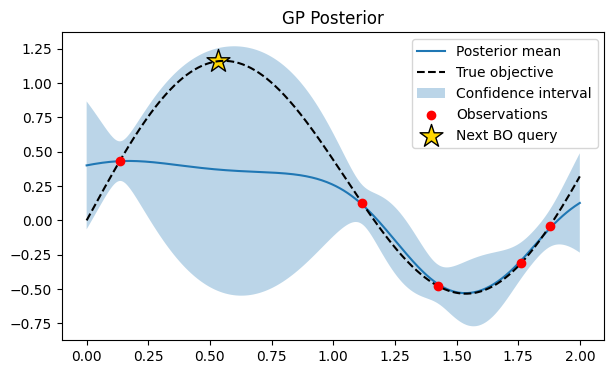

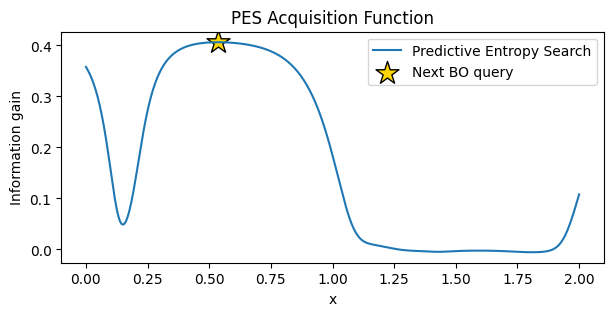

In [52]:

from botorch.acquisition.predictive_entropy_search import qPredictiveEntropySearch
# ======================
# construct optimal_inputs for PES
# （用 posterior mean 近似最优点）
# ======================
k = 20
topk_idx = torch.topk(mean, k=k).indices
optimal_inputs = X[topk_idx]  # (k, d)

# ======================
# qPredictiveEntropySearch
# ======================
acqf = qPredictiveEntropySearch(
    model=model,
    optimal_inputs=optimal_inputs,
    maximize=True,
).to(device=device, dtype=dtype)

# ======================
# evaluate acquisition on grid
# ======================
with torch.no_grad():
    pes = acqf(X_acq).squeeze(-1)

# ======================
# optimize acquisition
# ======================
candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=64,
)

# ======================
# plot GP posterior
# ======================
plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(
    X.cpu().numpy(),
    objective(X).cpu().numpy(),
    color="black",
    linestyle="--",
    label="True objective",
)

plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval",
)

plt.scatter(
    train_x.cpu().numpy(),
    train_y.cpu().numpy(),
    color="red",
    zorder=3,
    label="Observations",
)

plt.scatter(
    candidate.cpu().numpy(),
    objective(candidate).cpu().numpy(),
    marker="*",
    s=300,
    c="gold",
    edgecolors="black",
    label="Next BO query",
)

plt.title("GP Posterior")
plt.legend()
plt.show()

# ======================
# plot PES acquisition
# ======================
plt.figure(figsize=(7, 3))

plt.plot(
    X.cpu().numpy(),
    pes.cpu().numpy(),
    label="Predictive Entropy Search",
)

plt.scatter(
    candidate.cpu().numpy(),
    acq_value.cpu().numpy(),
    marker="*",
    s=300,
    c="gold",
    edgecolors="black",
    label="Next BO query",
)

plt.xlabel("x")
plt.ylabel("Information gain")
plt.title("PES Acquisition Function")
plt.legend()
plt.show()

# BO-MES(q=1)

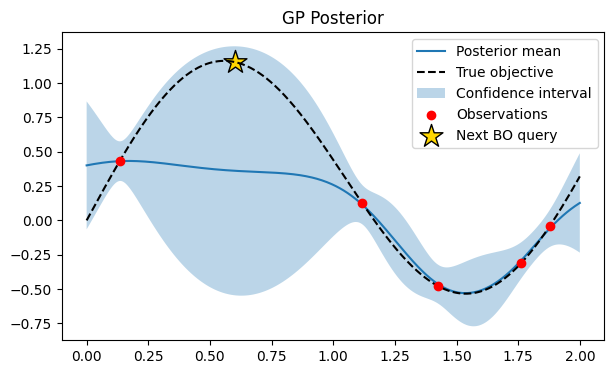

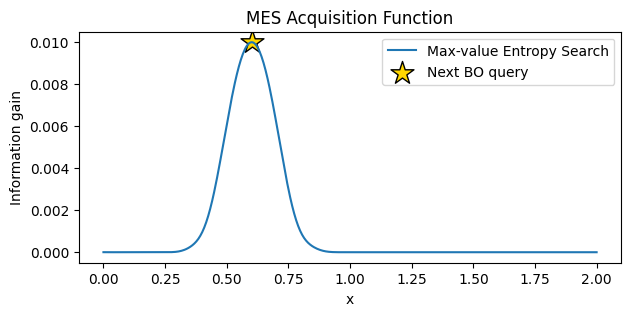

In [53]:
from botorch.acquisition.max_value_entropy_search import qMaxValueEntropy

# ======================
# candidate set for MES
# （离散化设计空间，非常关键）
# ======================
candidate_set = torch.rand(1000, 1, device=device, dtype=dtype)
candidate_set = bounds[0] + (bounds[1] - bounds[0]) * candidate_set

# ======================
# qMaxValueEntropy
# ======================
acqf = qMaxValueEntropy(
    model=model,
    candidate_set=candidate_set,
    num_mv_samples=32,   # max value samples
    num_y_samples=128,   # y samples at X
    maximize=True,
).to(device=device, dtype=dtype)

# ======================
# evaluate acquisition on grid
# ======================
with torch.no_grad():
    mes = acqf(X_acq).squeeze(-1)

# ======================
# optimize acquisition
# ======================
candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=64,
)

# ======================
# plot GP posterior
# ======================
plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(
    X.cpu().numpy(),
    objective(X).cpu().numpy(),
    "--",
    color="black",
    label="True objective",
)

plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval",
)

plt.scatter(
    train_x.cpu().numpy(),
    train_y.cpu().numpy(),
    color="red",
    zorder=3,
    label="Observations",
)

plt.scatter(
    candidate.cpu().numpy(),
    objective(candidate).cpu().numpy(),
    marker="*",
    s=300,
    c="gold",
    edgecolors="black",
    label="Next BO query",
)

plt.title("GP Posterior")
plt.legend()
plt.show()

# ======================
# plot MES acquisition
# ======================
plt.figure(figsize=(7, 3))

plt.plot(
    X.cpu().numpy(),
    mes.cpu().numpy(),
    label="Max-value Entropy Search",
)

plt.scatter(
    candidate.cpu().numpy(),
    acq_value.cpu().numpy(),
    marker="*",
    s=300,
    c="gold",
    edgecolors="black",
    label="Next BO query",
)

plt.xlabel("x")
plt.ylabel("Information gain")
plt.title("MES Acquisition Function")
plt.legend()
plt.show()